# 读取数据与初始化

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             confusion_matrix, classification_report,
                             RocCurveDisplay)
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

from patient import importances

# 1. 数据加载
data = pd.read_csv('dataSet/dataset_processed.csv')  # 替换为你的数据路径

# 2. 数据预处理
# 删除不相关的ID列
data = data.drop(['encounter_id', 'patient_id', 'hospital_id', 'icu_id'], axis=1)
data = data.drop(columns=['Unnamed: 83'], errors='ignore')


In [2]:
# 处理缺失值（示例处理，需根据实际数据调整）
# 数值列用中位数填充
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# 分类列用 'missing' 填充
categorical_cols = data.select_dtypes(include=['object']).columns
print(data[categorical_cols].isnull().sum())
# data = data.dropna(subset=categorical_cols)
data[categorical_cols] =data[categorical_cols].fillna('missing')
data[categorical_cols].isnull().sum()

ethnicity               1395
gender                    25
icu_admit_source         112
icu_stay_type              0
icu_type                   0
apache_3j_bodysystem    1662
apache_2_bodysystem     1662
dtype: int64


ethnicity               0
gender                  0
icu_admit_source        0
icu_stay_type           0
icu_type                0
apache_3j_bodysystem    0
apache_2_bodysystem     0
dtype: int64

In [3]:
# 3. 特征工程
# 定义分类特征和数值特征
categorical_features = ['elective_surgery', 'ethnicity', 'gender', 
                       'icu_admit_source', 'icu_stay_type', 'icu_type',
                       'apache_3j_bodysystem', 'apache_2_bodysystem']
numeric_features = [col for col in data.columns 
                   if col not in categorical_features + ['hospital_death']]

# 4. 创建预处理管道
# 这里加入SimpleImputer来处理缺失值
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),  # 对数值列进行中位数填充
            ('scaler', StandardScaler())  # 标准化
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # 对分类列进行'missing'填充
            ('encoder', OneHotEncoder(handle_unknown='ignore'))  # 独热编码
        ]), categorical_features)
    ])



In [4]:
# 5. 划分数据集
X = data.drop('hospital_death', axis=1)
y = data['hospital_death']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


# 6. 创建模型管道（去掉 class_weight 参数）
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', max_depth=5))
])

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())  # 去掉 class_weight
])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        # device = "cuda",
        scale_pos_weight=1, 
        eval_metric='logloss'))
])


# 7. 训练和评估函数
def train_evaluate_model(pipeline, model_name):
    # 训练模型
    pipeline.fit(X_train, y_train)
    
    # 预测
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # 评估指标
    print(f"\n{model_name} 评估结果:")
    print("准确率:", accuracy_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_proba))
    print("\n分类报告:")
    print(classification_report(y_test, y_pred))
    
    # 绘制ROC曲线
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test)
    plt.title(f'{model_name} ROC Curve')
    plt.show()
    
    # 混淆矩阵
    cm = confusion_matrix(y_test, y_pred)
    print("混淆矩阵:")
    print(cm)


logisticsRegression 评估结果:
准确率: 0.7987243090007087
AUC: 0.8746922100419585

分类报告:
              precision    recall  f1-score   support

           0       0.97      0.80      0.88     16760
           1       0.27      0.78      0.40      1583

    accuracy                           0.80     18343
   macro avg       0.62      0.79      0.64     18343
weighted avg       0.91      0.80      0.84     18343



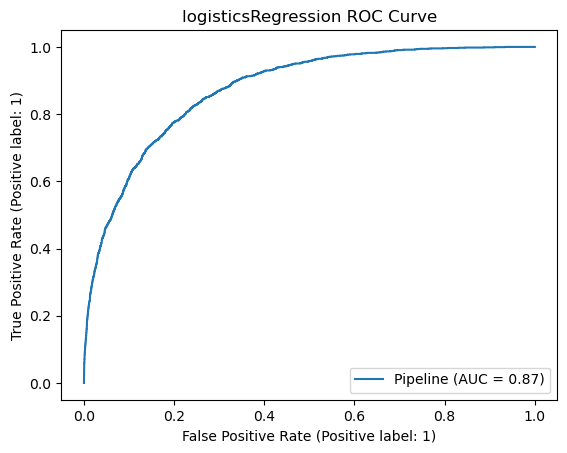

混淆矩阵:
[[13424  3336]
 [  356  1227]]


In [5]:
# 8. 训练和评估模型
train_evaluate_model(logreg_pipeline, "logisticsRegression")


decisionTree 评估结果:
准确率: 0.773973722946083
AUC: 0.8223585696473721

分类报告:
              precision    recall  f1-score   support

           0       0.97      0.78      0.86     16760
           1       0.23      0.71      0.35      1583

    accuracy                           0.77     18343
   macro avg       0.60      0.74      0.61     18343
weighted avg       0.90      0.77      0.82     18343



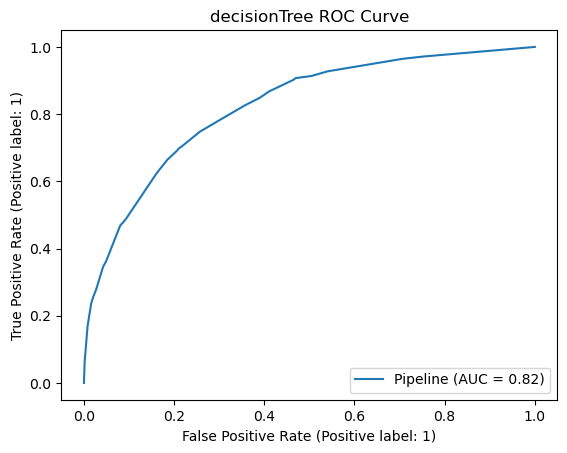

混淆矩阵:
[[13078  3682]
 [  464  1119]]


In [6]:
train_evaluate_model(tree_pipeline, "decisionTree")


gradient 评估结果:
准确率: 0.9289102109796653
AUC: 0.8838286643438563

分类报告:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     16760
           1       0.72      0.28      0.41      1583

    accuracy                           0.93     18343
   macro avg       0.83      0.64      0.69     18343
weighted avg       0.92      0.93      0.91     18343



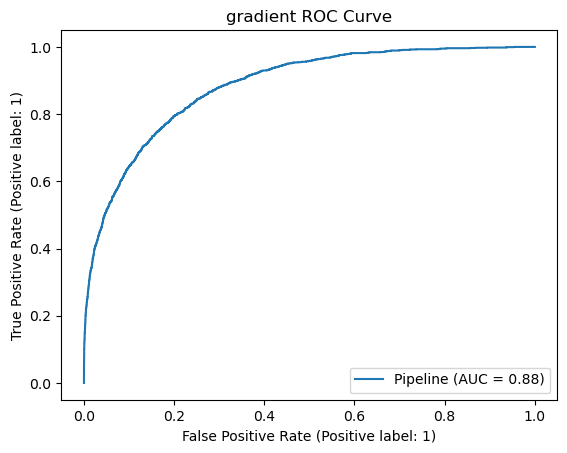

混淆矩阵:
[[16589   171]
 [ 1133   450]]


In [7]:
train_evaluate_model(gb_pipeline, "gradient")


XGBoost 评估结果:
准确率: 0.9273837431172655
AUC: 0.880374979081138

分类报告:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     16760
           1       0.66      0.33      0.44      1583

    accuracy                           0.93     18343
   macro avg       0.80      0.66      0.70     18343
weighted avg       0.92      0.93      0.92     18343



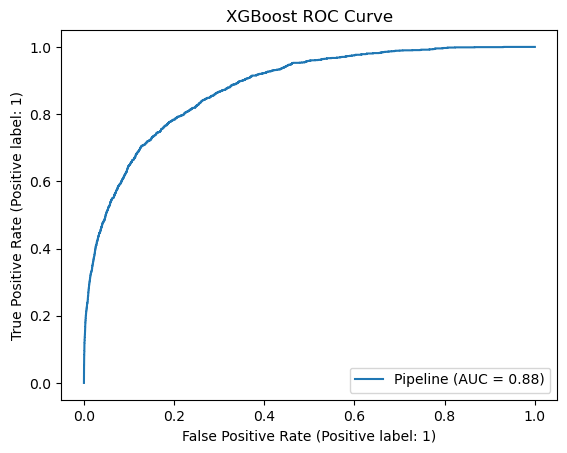

混淆矩阵:
[[16488   272]
 [ 1060   523]]


In [8]:
train_evaluate_model(xgb_pipeline, "XGBoost")

In [9]:
import joblib

# 保存模型
joblib.dump(xgb_pipeline, 'xgb_pipeline.joblib')

print("Model saved as 'xgb_pipeline.joblib'")

Model saved as 'xgb_pipeline.joblib'


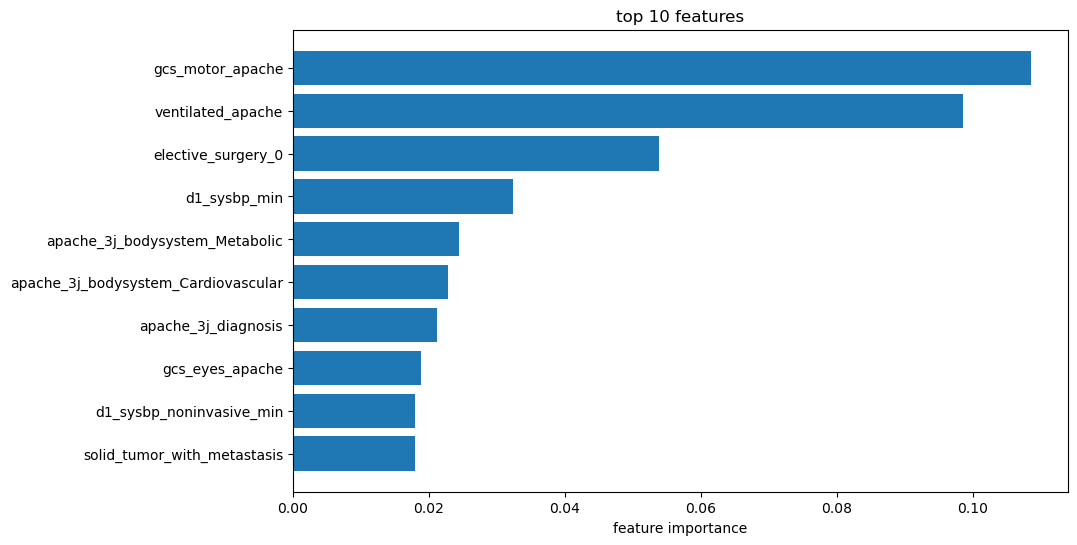

In [10]:
# 9. 特征重要性分析（以决策树为例）
# 提取预处理后的特征名称
preprocessor.fit(X)
feature_names = (numeric_features + 
                list(preprocessor.named_transformers_['cat']
                     .get_feature_names_out(categorical_features)))

# 获取特征重要性
# importances = tree_pipeline.named_steps['classifier'].feature_importances_
importances = xgb_pipeline.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[-10:]  # 取最重要的10个特征

# 绘制特征重要性
plt.figure(figsize=(10, 6))
plt.title('top 10 features')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('feature importance')
plt.show()


In [20]:
top_features = [feature_names[i] for i in indices]
print(top_features)
top_features = ['solid_tumor_with_metastasis', 'd1_sysbp_noninvasive_min', 'gcs_eyes_apache', 'apache_3j_diagnosis', 'apache_3j_bodysystem', 'd1_sysbp_min', 'elective_surgery', 'ventilated_apache', 'gcs_motor_apache']
data[top_features].describe()
# 使用 .head() 方法查看前 5 行数据

['solid_tumor_with_metastasis', 'd1_sysbp_noninvasive_min', 'gcs_eyes_apache', 'apache_3j_diagnosis', 'apache_3j_bodysystem_Cardiovascular', 'apache_3j_bodysystem_Metabolic', 'd1_sysbp_min', 'elective_surgery_0', 'ventilated_apache', 'gcs_motor_apache']


,solid_tumor_with_metastasis,d1_sysbp_noninvasive_min,gcs_eyes_apache,apache_3j_diagnosis,d1_sysbp_min,elective_surgery,ventilated_apache,gcs_motor_apache
count,91713.000000,91713.000000,91713.000000,91713.000000,91713.000000,91713.000000,91713.000000,91713.000000
mean,0.020477,96.982190,3.476138,556.425298,96.922268,0.183736,0.323182,5.482156
std,0.141626,20.589027,0.944878,460.764423,20.660033,0.387271,0.467694,1.277178
min,0.000000,41.030000,1.000000,0.010000,41.000000,0.000000,0.000000,1.000000
25%,0.000000,84.000000,3.000000,203.010000,84.000000,0.000000,0.000000,6.000000
50%,0.000000,96.000000,4.000000,409.020000,96.000000,0.000000,0.000000,6.000000
75%,0.000000,110.000000,4.000000,703.030000,110.000000,0.000000,1.000000,6.000000
max,1.000000,160.000000,4.000000,2201.050000,160.000000,1.000000,1.000000,6.000000


In [24]:
#看看每个重要特征能取什么值
for feature in top_features:
    print(data[feature].value_counts())

solid_tumor_with_metastasis
0.0    89835
1.0     1878
Name: count, dtype: int64
d1_sysbp_noninvasive_min
96.0     2928
90.0     2146
91.0     2119
92.0     2061
93.0     1967
         ... 
156.0      57
158.0      53
42.0       46
159.0      40
157.0      40
Name: count, Length: 120, dtype: int64
gcs_eyes_apache
4.0    64896
3.0    13863
1.0     8274
2.0     4680
Name: count, dtype: int64
apache_3j_diagnosis
501.05     4481
107.01     4350
106.01     3923
403.01     3789
703.03     3106
           ... 
1803.01       1
301.04        1
1101.05       1
0.01          1
1202.01       1
Name: count, Length: 399, dtype: int64
apache_3j_bodysystem
Cardiovascular          29999
Neurological            11896
Sepsis                  11740
Respiratory             11609
Gastrointestinal         9026
Metabolic                7650
Trauma                   3842
Genitourinary            2172
missing                  1662
Musculoskeletal/Skin     1166
Hematological             638
Gynecological         

# 10. 堆叠法模型

cross_validate_accuracy: [0.85563975 0.82303876 0.8296898  0.83376949 0.82477374]
Average accuracy: 0.8333823097992052


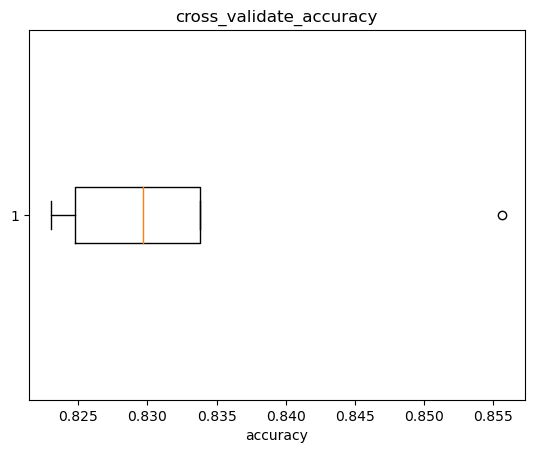

In [11]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.model_selection import cross_val_score,cross_validate


# 1. 创建基础模型（第一层模型）
base_learners = [
    ('tree', Pipeline(steps=[
        ('preprocessor', preprocessor),  # 使用同样的预处理管道
        ('classifier', DecisionTreeClassifier(class_weight='balanced', max_depth=5))
    ])),
    ('gb', Pipeline(steps=[
        ('preprocessor', preprocessor),  # 使用同样的预处理管道
        ('classifier', GradientBoostingClassifier())
    ])),
    ('xgb', Pipeline(steps=[
        ('preprocessor', preprocessor),  # 使用同样的预处理管道
        ('classifier', xgb.XGBClassifier(
            # tree_method='gpu_hist',  # 使用GPU加速
            # gpu_id=0,  # 选择GPU设备（如果有多个GPU可以选择其他编号）
            scale_pos_weight=1, 
            eval_metric='logloss'))
    ]))
]

# 2. 创建元模型（第二层模型）
meta_model = LogisticRegression(class_weight='balanced', max_iter=1000)

# 3. 创建堆叠法模型
stacking_pipeline = StackingClassifier(
    estimators=base_learners, 
    final_estimator=meta_model
)

# 4. 使用交叉验证对堆叠法模型进行评估
cv_scores = cross_val_score(stacking_pipeline, X, y, cv=5, scoring='accuracy')
print(f"cross_validate_accuracy: {cv_scores}")
print(f"Average accuracy: {cv_scores.mean()}")
# 绘制交叉验证准确率的箱型图
plt.boxplot(cv_scores, vert=False)
plt.title('cross_validate_accuracy')
plt.xlabel('accuracy')
plt.show()


cross_validate_accuracy: [0.85558524 0.82303876 0.8296898  0.83382401 0.82482826]
cross_validate AUC: [0.88284427 0.87840054 0.88012637 0.87092937 0.86830749]
Average accuracy: 0.833393214329973
Average AUC: 0.876121606899876


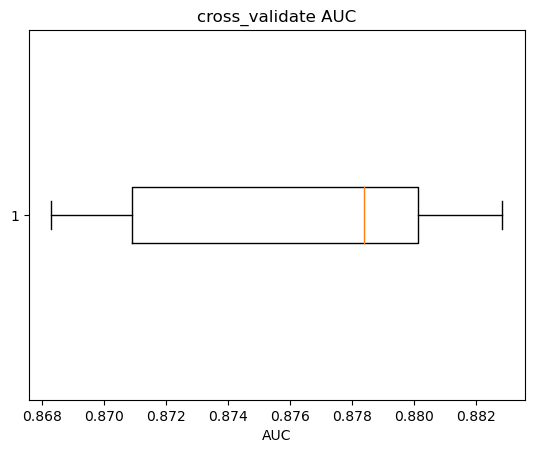

In [12]:
# 5. 使用 cross_validate 进行详细的交叉验证评估
cv_results = cross_validate(stacking_pipeline, X, y, cv=5, 
                            scoring=['accuracy', 'roc_auc'], return_train_score=False)
print(f"cross_validate_accuracy: {cv_results['test_accuracy']}")
print(f"cross_validate AUC: {cv_results['test_roc_auc']}")
print(f"Average accuracy: {cv_results['test_accuracy'].mean()}")
print(f"Average AUC: {cv_results['test_roc_auc'].mean()}")

# 绘制交叉验证 AUC 的箱型图
plt.boxplot(cv_results['test_roc_auc'], vert=False)
plt.title('cross_validate AUC')
plt.xlabel('AUC')
plt.show()

# 交互界面

In [26]:
if True:    
    import tkinter as tk
    from tkinter import ttk, messagebox
    import pandas as pd
    import numpy as np
    import joblib
    load_pipeline = joblib.load('xgb_pipeline.joblib')
    # 假设你已经训练好了这些模型，并且已经保存为joblib文件
    
    # 获取相关性最高的特征
    # top_features = ['elective_surgery', 'ethnicity', 'gender', 'apache_3j_bodysystem', 'icu_admit_source']
    top_features = [
    'apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob', 'd1_spo2_min',
    'ventilated_apache', 'd1_sysbp_noninvasive_min', 'd1_sysbp_min',
]
    # 创建主窗口
    root = tk.Tk()
    root.title("Hospital Death Prediction")
        
    # 设置窗口大小
    root.geometry("400x450")
    root.config(bg="#f5f5f5")
    
    # 设置标题
    title_label = ttk.Label(root, text="Predict Patient's Outcome", font=("Helvetica", 16), anchor="center")
    title_label.pack(pady=10)
    
    # 创建标签和输入框
    labels = {}
    entries = {}
    
    frame = ttk.Frame(root, padding="10")
    frame.pack(padx=20, pady=20)
    
    for feature in top_features:
        # 为每个特征创建标签
        label = ttk.Label(frame, text=feature, font=("Helvetica", 10), anchor="w")
        label.grid(row=top_features.index(feature), column=0, pady=5, sticky="w")
    
        # 为每个特征创建输入框
        entry = ttk.Entry(frame, width=25, font=("Helvetica", 10))
        entry.grid(row=top_features.index(feature), column=1, pady=5)
        entries[feature] = entry
    
    # 定义预测函数
    def predict():
        input_data = {}
    
        # 获取用户输入的数据
        for feature in top_features:
            value = entries[feature].get()
            if value:
                input_data[feature] = value
            else:
                # 如果输入为空，则用众数代替
                input_data[feature] = data[feature].mode()[0]  # 使用训练数据中的众数
    
        # 补齐所有模型需要的特征
        all_features = [ 'age', 'bmi', 'elective_surgery', 'ethnicity', 
                        'gender', 'height', 'icu_admit_source',  'icu_stay_type', 'icu_type', 'pre_icu_los_days',
                        'weight', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache',
                        'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'heart_rate_apache',
                        'intubated_apache', 'map_apache', 'resprate_apache', 'temp_apache', 'ventilated_apache', 'd1_diasbp_max',
                        'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max',
                        'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min',
                        'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max', 'd1_sysbp_min',
                        'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min', 'd1_temp_max', 'd1_temp_min', 'h1_diasbp_max',
                        'h1_diasbp_min', 'h1_diasbp_noninvasive_max', 'h1_diasbp_noninvasive_min', 'h1_heartrate_max',
                        'h1_heartrate_min', 'h1_mbp_max', 'h1_mbp_min', 'h1_mbp_noninvasive_max', 'h1_mbp_noninvasive_min',
                        'h1_resprate_max', 'h1_resprate_min', 'h1_spo2_max', 'h1_spo2_min', 'h1_sysbp_max', 'h1_sysbp_min',
                        'h1_sysbp_noninvasive_max', 'h1_sysbp_noninvasive_min', 'd1_glucose_max', 'd1_glucose_min',
                        'd1_potassium_max', 'd1_potassium_min', 'apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob',
                        'aids', 'cirrhosis', 'diabetes_mellitus', 'hepatic_failure', 'immunosuppression', 'leukemia',
                        'lymphoma', 'solid_tumor_with_metastasis', 'apache_3j_bodysystem', 'apache_2_bodysystem']
        
        # 填补所有缺失的特征（包括非用户输入的特征），用众数填补
        for feature in all_features:
            if feature not in input_data:  # 如果用户没有提供该特征
                input_data[feature] = data[feature].mode()[0]  # 用训练数据中的众数填充
    
        # 转换输入数据为DataFrame
        input_df = pd.DataFrame([input_data])
        
        prediction = load_pipeline.predict(input_df)
        prediction_proba = load_pipeline.predict_proba(input_df)[:, 1]
    
        # 显示预测结果
        result = "Death" if prediction[0] == 1 else "Survival"
        prob = prediction_proba[0]
        messagebox.showinfo("Prediction Result", f"Predicted Outcome: {result}\nProbability: {prob:.2f}")
    
    
    
    # 创建预测按钮
    predict_button = ttk.Button(root, text="Predict", command=predict, width=20)
    predict_button.pack(pady=20)
    
    # 运行主循环
    root.mainloop()
    
    
